# Import Libraries

In [1]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from skimage.transform import resize

from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax
from sklearn.metrics import classification_report, confusion_matrix

2025-08-26 00:55:39.965269: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-26 00:55:39.965329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-26 00:55:39.966998: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 1. Configuration and Data Paths

In [ ]:
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

train_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Training"
test_dir = r"e:\HealthCareProject\DeepLearning_module\notebook\img_data\brain_tumor_mri_dataset\Testing"


X_train = [] #Training Dataset
Y_train = [] #Training Labels

image_size=224

for label in labels:
    path = os.path.join(train_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

for label in labels:
    path = os.path.join(test_dir, label)
    class_num = labels.index(label)
    for img in os.listdir(path):
        img_array = plt.imread(os.path.join(path, img))
        img_resized = resize(img_array, (image_size, image_size, 3))
        X_train.append(img_resized)
        Y_train.append(class_num)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

In [4]:
#Number of sample = 7023
X_train.shape

(7023, 224, 224, 3)

In [5]:
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

In [6]:
#After shuffling sample size remains same
X_train.shape

(7023, 224, 224, 3)

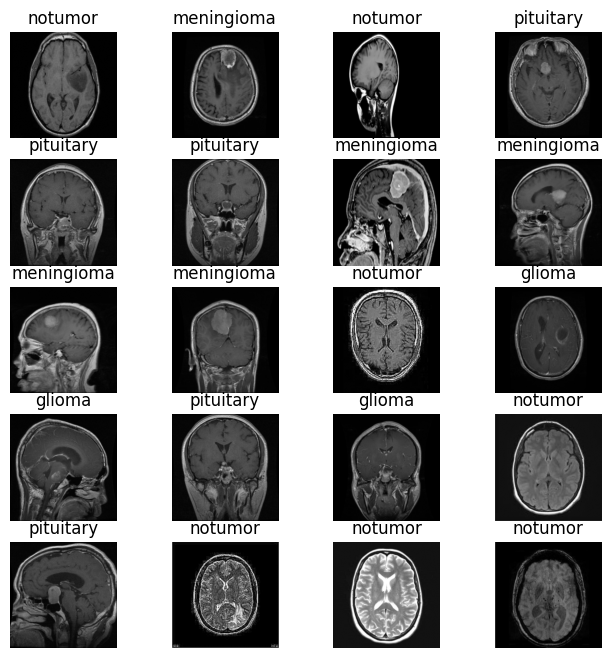

In [7]:
#plotting the images
plt.figure(figsize=(8,8))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_train[i])
    plt.title(labels[Y_train[i]])
    plt.axis("off")
plt.show()

In [8]:
# Split the data into training and testing and validation
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

In [9]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

# convert string to categorical
y_train_new = to_categorical(Y_train, num_classes=4)
y_valid_new = to_categorical(Y_valid, num_classes=4)
y_test_new = to_categorical(Y_test, num_classes=4)

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define image size
image_size = 224  # You can adjust based on your dataset

# Load VGG16 model with pre-trained weights
base_model = VGG16(input_shape=(image_size, image_size, 3), include_top=False, weights='imagenet')

# Unfreeze some layers in the base model (last 4 conv blocks = last 4*2-3? check layers count)
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Assuming 4 classes
])

# Compile the model
model.compile(Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('VGG16_model.h5', monitor='val_loss', save_best_only=True)

# Model summary
model.summary()


58889256/58889256 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 128)               65664     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 51

In [11]:
# Fit the model
history = model.fit(datagen.flow(X_train, y_train_new, batch_size=32),
                    epochs=12,  # Increase the number of epochs as needed
                    validation_data=(X_valid, y_valid_new),
                    callbacks=[early_stopping, checkpoint])

Epoch 1/12


I0000 00:00:1756170158.009095     181 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 [==============================] - ETA: 0s - loss: 1.4020 - accuracy: 0.2591

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


158/158 [==============================] - 102s 447ms/step - loss: 1.4020 - accuracy: 0.2591 - val_loss: 1.3807 - val_accuracy: 0.2954
Epoch 2/12
158/158 [==============================] - 69s 437ms/step - loss: 1.3783 - accuracy: 0.2595 - val_loss: 1.2385 - val_accuracy: 0.2972
Epoch 3/12
158/158 [==============================] - 70s 438ms/step - loss: 1.2386 - accuracy: 0.3762 - val_loss: 1.0853 - val_accuracy: 0.4573
Epoch 4/12
158/158 [==============================] - 70s 439ms/step - loss: 1.1229 - accuracy: 0.4624 - val_loss: 1.0206 - val_accuracy: 0.6246
Epoch 5/12
158/158 [==============================] - 70s 442ms/step - loss: 0.9927 - accuracy: 0.5453 - val_loss: 0.8381 - val_accuracy: 0.6281
Epoch 6/12
158/158 [==============================] - 70s 442ms/step - loss: 0.8228 - accuracy: 0.6551 - val_loss: 0.5833 - val_accuracy: 0.8327
Epoch 7/12
158/158 [==============================] - 70s 443ms/step - loss: 0.6461 - accuracy: 0.7476 - val_loss: 0.5176 - val_accuracy: 0.

In [13]:
# Load the best model
model = load_model('VGG16_model.h5')

In [19]:
from IPython.display import FileLink

# This will generate a direct link to the saved file
# You can click this link to start the download
FileLink('VGG16_model.h5')

/kaggle/working/VGG16_model.h5

44/44 [==============================] - 15s 337ms/step - loss: 0.2036 - accuracy: 0.9267


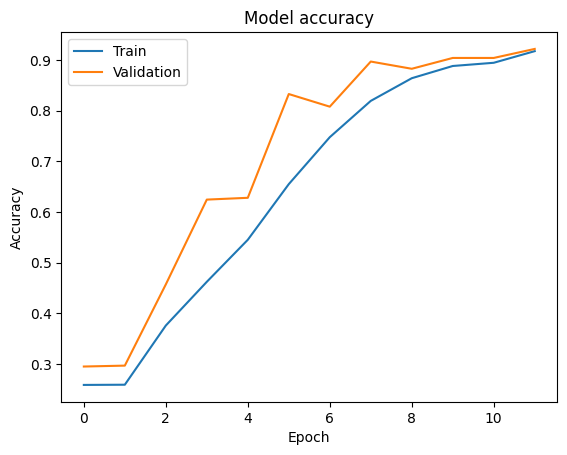

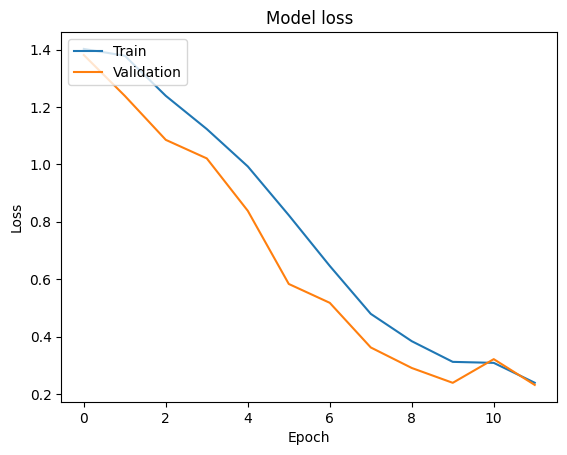

In [14]:
#Evaluate the model
model.evaluate(X_test, y_test_new)

# Plot the accuracy and loss
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

44/44 [==============================] - 6s 134ms/step


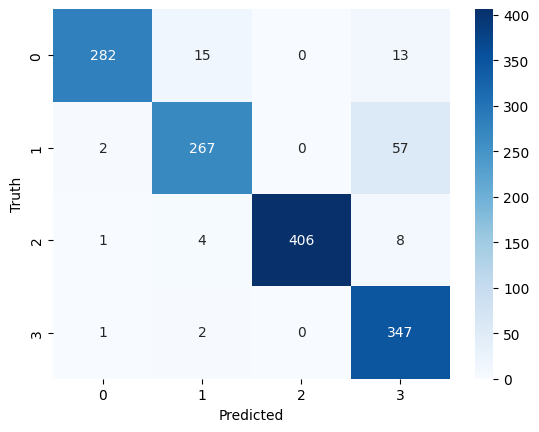

In [15]:
# Predict the model
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [16]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred, target_names=labels))

              precision    recall  f1-score   support

      glioma       0.99      0.91      0.95       310
  meningioma       0.93      0.82      0.87       326
     notumor       1.00      0.97      0.98       419
   pituitary       0.82      0.99      0.90       350

    accuracy                           0.93      1405
   macro avg       0.93      0.92      0.92      1405
weighted avg       0.93      0.93      0.93      1405



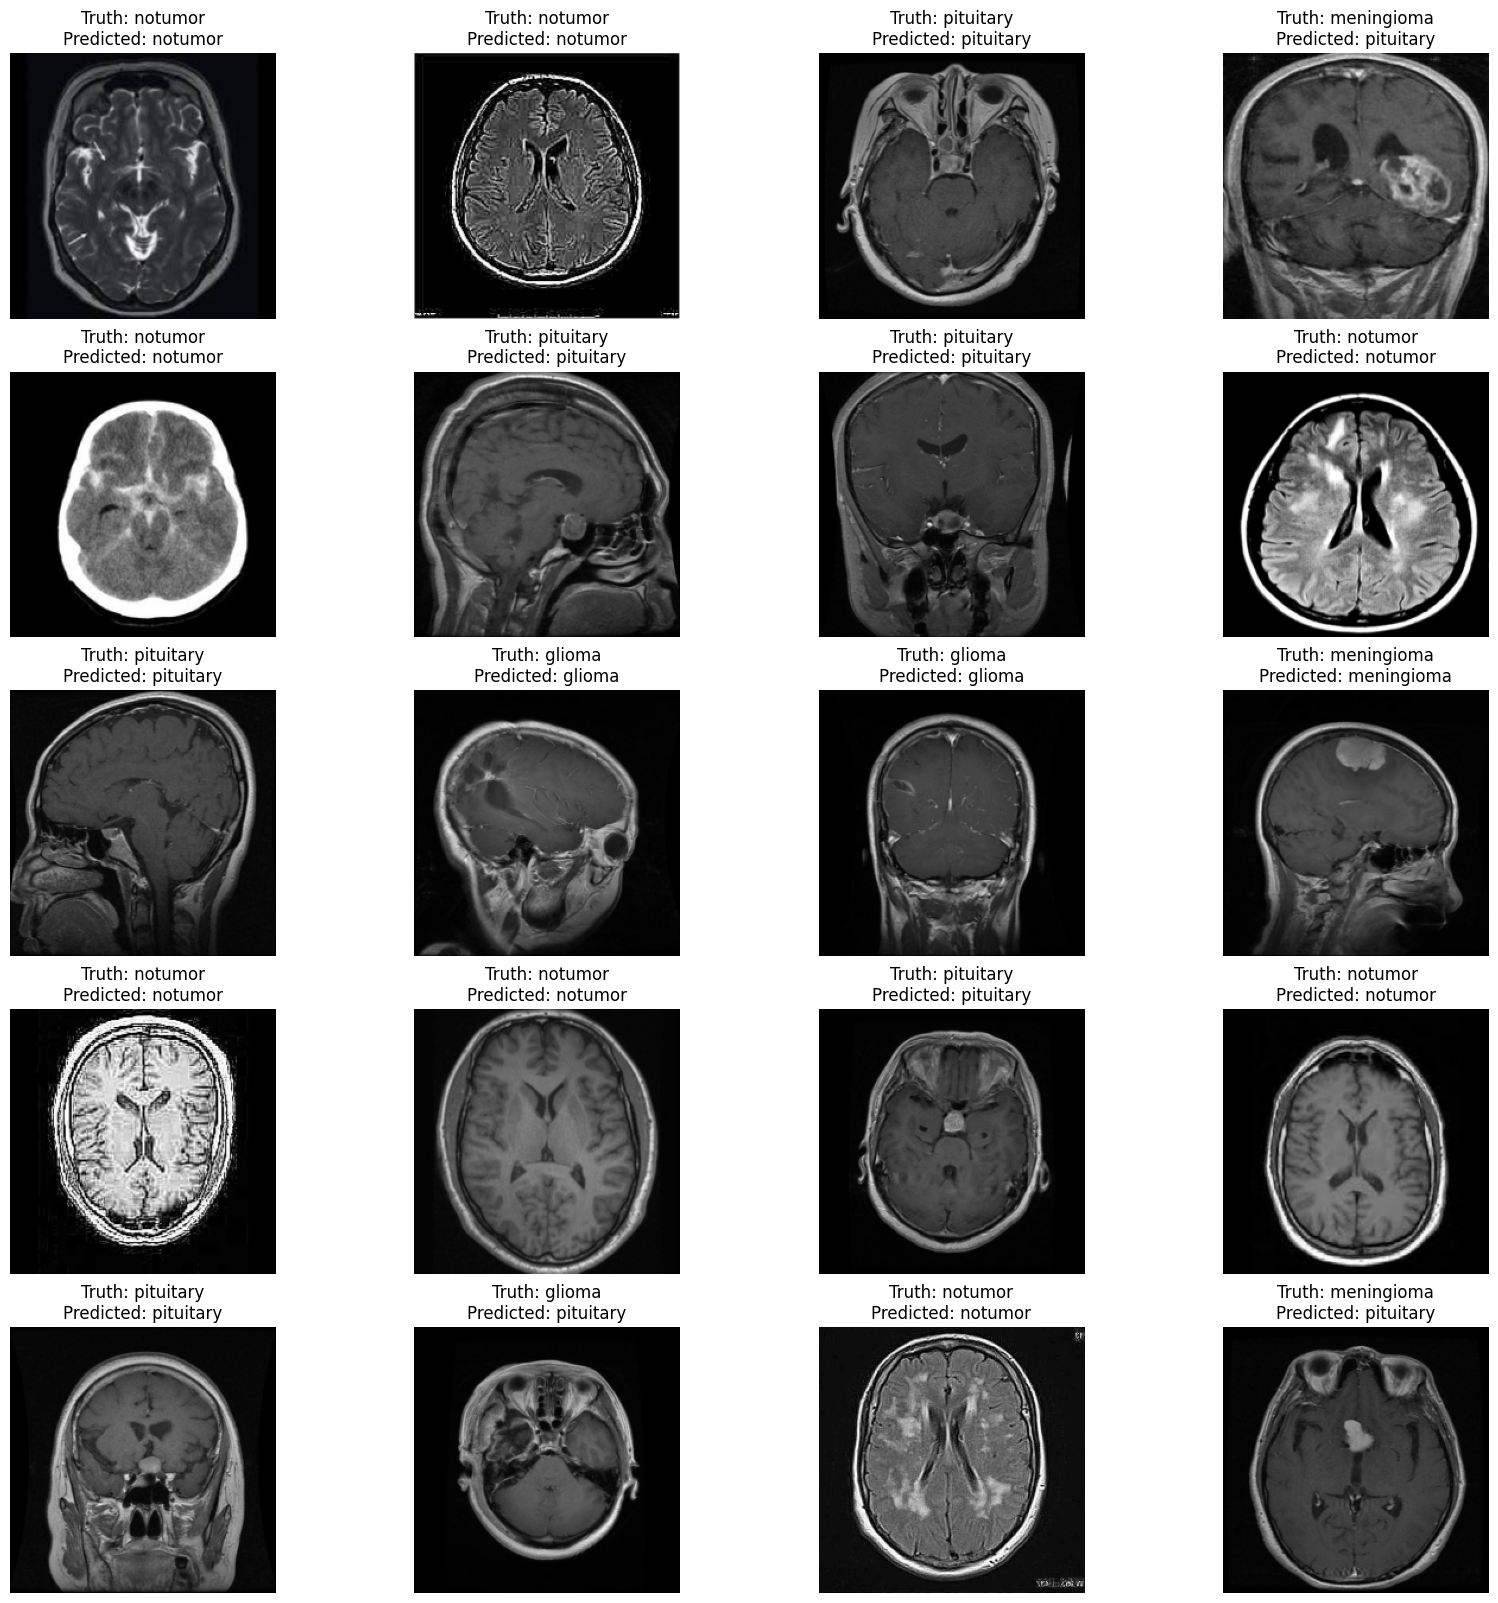

In [17]:
# Visualizing Model Predictions
plt.figure(figsize=(20,20))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Truth: {labels[Y_test[i]]}\nPredicted: {labels[y_pred[i]]}")
    plt.axis('off')
plt.show()

In [18]:
#testing accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test, y_pred))

0.9266903914590747
